## Ejercicio 1  

Implemente el algoritmo de retropropagación para un **perceptrón multicapa** de forma que se pueda elegir libremente la cantidad de capas de la red y de neuronas en cada capa. Pruébelo entrenando una red de estructura apropiada para resolver el problema **XOR**, con sus particiones de **entrenamiento** y **prueba** correspondientes (datos de la Guía de Trabajos Prácticos 1).  


## Perceptron Multicapa

### Importaciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Definición de la estructura de la red neuronal

En este bloque se especifica la **topología de la red neuronal multicapa** mediante el vector `estructura`:  

- `estructura = np.array([2, 2, 1])`  
  - **2** → Número de **entradas** (sin contar el sesgo).  
  - **2** → Número de **neuronas en la capa oculta**.  
  - **1** → Número de **neuronas de salida**.  

A partir de esto se calculan:  
- `cant_capas = len(estructura) - 1` → Número de capas con pesos entrenables (ocultas + salida).  
- `cant_salidas = estructura[-1]` → Número de salidas de la red (último valor del vector).  


In [2]:
estructura = np.array([2, 2, 1])
cant_capas = len(estructura) - 1
cant_salidas = estructura[-1]

### Cargamos los datos

In [3]:
def load_data(path): 
  
  data = np.loadtxt(path, delimiter=",")
  cant_entradas = estructura[0]

  X = data[:, :cant_entradas]
  y = data[:, -1]

  X = np.hstack(( -np.ones((X.shape[0], 1)), X ))

  return X, y

In [4]:
X_train, Y_train = load_data("./data/XOR_trn.csv")
#print(X_train)

### Inicialización de los pesos de la red neuronal

La función `init_weights()` genera los pesos iniciales de la red multicapa.  

- Se crea una lista `w` donde se almacenarán las matrices de pesos de cada capa.  
- Para cada capa `i`:  
  - `n_neuronas = estructura[i+1]` → Número de **neuronas en la capa destino**.  
  - `n_entradas = estructura[i] + 1` → Número de **entradas para cada neurona**, se suma `+1` para incluir el **bias**.  
  - `w_aux = np.random.rand(n_neuronas, n_entradas) - 0.5` → Matriz de pesos iniciales de tamaño  
   

Los valores se generan aleatoriamente en el rango $[-0.5, 0.5]$.  
- Cada matriz de pesos `w_aux` se agrega a la lista `w`.  

Al final, `w` contiene todas las matrices de pesos que conectan capa a capa en la red.  


In [5]:
def init_weights(): 
  w = []

  for i in range(cant_capas): 
    n_neuronas = estructura[i+1]
    n_entradas = estructura[i] + 1 # Sumo uno por el bias
    w_aux = np.random.rand( n_neuronas, n_entradas)-0.5
    w.append(w_aux)

  return w
w = init_weights()

### Funciones de activacion

- **`sigmoidea(v)`**  
  Implementa la función de activación sigmoidea **bipolar**, también llamada tangente hiperbólica escalada:  

  $$
  f(v) = \frac{2}{1 + e^{-v}} - 1
  $$

  Rango de salida es $(-1, 1)$.  

- **`d_sigmoidea(y)`**  
  $$
  f'(y) = \frac{d}{dv} f(v) = (1+y)(1-y)
  $$

In [6]:
def sigmoidea(v):
    return ((2/(1+np.exp(-v)))-1)

def d_sigmoidea(y):
    return ((1+y)*(1-y))

# Vector para almacenar las salidas de cada capa.
y = np.empty(cant_capas, dtype=object)

# Vector para almacenar los términos de error (deltas) de cada capa durante la retropropagación
delta = np.empty(cant_capas, dtype=object)

### Propagación hacia delante

In [7]:
def forward_prop(entradas):
  #entradas = X_train[patron]
  for capa in range(cant_capas): 
      # Salida lineal
      z = np.dot(w[capa], entradas)
      # Salida no lineal
      y[capa] = sigmoidea(z)
      entradas = np.hstack(([-1], y[capa]))
  return y

### Propagación hacia atras

In [8]:
def back_prop(y_deseada, y): 
  e = y_deseada - y[-1]
  delta[-1] = e * 1/2 * d_sigmoidea(y[-1])

  for i in range(cant_capas - 1, 0, -1): 
    w_i = w[i][:, 1:].T # Elimino la col del bias
    d = np.dot(w_i, delta[i])
    delta[i-1] = d*(1/2)*d_sigmoidea(y[i-1])

  return delta


### Actualizamos los pesos

In [9]:
def actualizacion(patron, delta, tasa): 
  entradas = X_train[patron]
  for capa in range(cant_capas): 
    delta_peso = tasa * np.outer(delta[capa], entradas)
    w[capa] += delta_peso

    entradas = np.hstack(([-1], y[capa]))

  return w

## Entrenamiento

In [10]:
# Hiperparámetros
epocas = 30
tasa_aprendizaje = 0.01
perc_error_max = 0.1   # Tolerancia máxima de error (10%)

# Métricas por época
errores_por_epoca = []
mse_por_epoca = []

# Entrenamiento
for epoca in range(epocas): 
    # Fase de entrenamiento (forward + backprop + actualización)
    for patron in range(len(X_train)):
        y_d = Y_train[patron]
        y = forward_prop(X_train[patron])                     # Propagación hacia adelante
        delta = back_prop(y_d, y)                    # Retropropagación del error
        w = actualizacion(patron, delta, tasa_aprendizaje)  # Actualización de pesos

    # Evaluación del desempeño
    errores = 0     # Cantidad de predicciones incorrectas
    cont_mse = 0.0  # Error cuadratico medio sobre todos los patrones  

    for patron in range(len(X_train)):
        
        y = forward_prop(X_train[patron])

        yc = np.sign(y[-1])  # Clasificación final

        if (Y_train[patron] != yc).any(): 
            errores += 1
        
        cont_mse += np.sum(np.square(Y_train[patron] - y[-1]))

    # Guardar métricas
    # Calculamos el error cuadratico medio promedio
    mse = cont_mse / len(X_train)
    mse_por_epoca.append(mse)

    perc_error = errores / len(X_train)
    errores_por_epoca.append(perc_error)

    # Porcentaje de acierto obtenido
    acierto = 100 * (1 - perc_error)

    # Imprimir resultados
    print(f"Época {epoca+1}/{epocas} → Errores: {errores}/{len(X_train)} | Acierto: {acierto:.2f}% | MSE: {mse:.6f}")

    # Criterio de parada por convergencia
    if perc_error < perc_error_max: 
        print("🟢 Finalizado por convergencia (error < perc_error_max)")
        break
else:
    print("🔁 Finalizado por límite de épocas")

Época 1/30 → Errores: 993/2000 | Acierto: 50.35% | MSE: 1.003425
Época 2/30 → Errores: 993/2000 | Acierto: 50.35% | MSE: 1.002992
Época 3/30 → Errores: 993/2000 | Acierto: 50.35% | MSE: 1.002818
Época 4/30 → Errores: 993/2000 | Acierto: 50.35% | MSE: 1.002738
Época 5/30 → Errores: 993/2000 | Acierto: 50.35% | MSE: 1.002693
Época 6/30 → Errores: 993/2000 | Acierto: 50.35% | MSE: 1.002662
Época 7/30 → Errores: 993/2000 | Acierto: 50.35% | MSE: 1.002634
Época 8/30 → Errores: 993/2000 | Acierto: 50.35% | MSE: 1.002604
Época 9/30 → Errores: 993/2000 | Acierto: 50.35% | MSE: 1.002569
Época 10/30 → Errores: 993/2000 | Acierto: 50.35% | MSE: 1.002523
Época 11/30 → Errores: 993/2000 | Acierto: 50.35% | MSE: 1.002462
Época 12/30 → Errores: 993/2000 | Acierto: 50.35% | MSE: 1.002378
Época 13/30 → Errores: 993/2000 | Acierto: 50.35% | MSE: 1.002255
Época 14/30 → Errores: 993/2000 | Acierto: 50.35% | MSE: 1.002068
Época 15/30 → Errores: 993/2000 | Acierto: 50.35% | MSE: 1.001760
Época 16/30 → Error

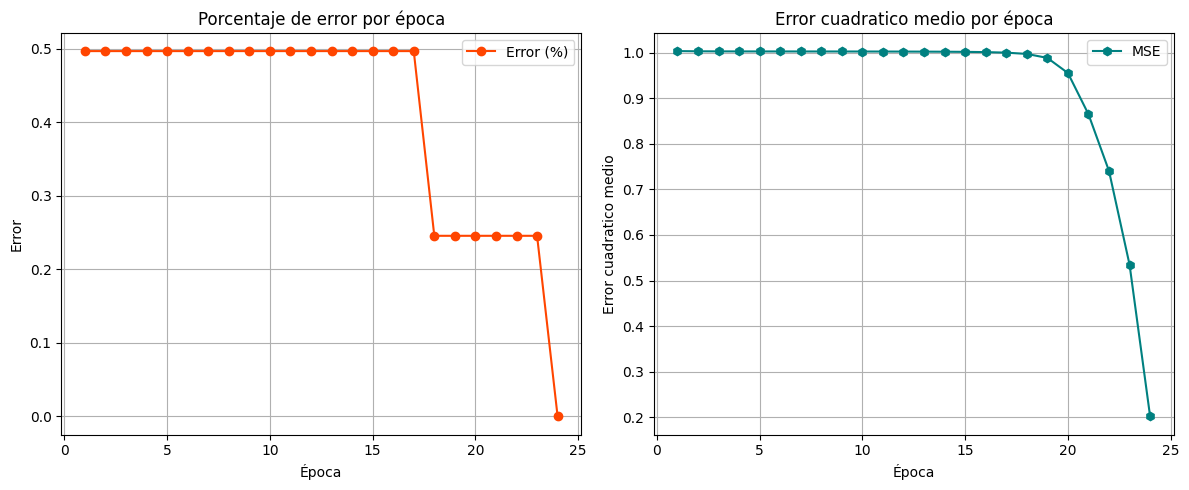

In [11]:
epocas = range(1, len(errores_por_epoca) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de errores
ax[0].plot(epocas, errores_por_epoca, marker='o', color='orangered', label='Error (%)')
ax[0].set_title('Porcentaje de error por época')
ax[0].set_xlabel('Época')
ax[0].set_ylabel('Error')
ax[0].grid(True)
ax[0].legend()

# Gráfico de MSE
ax[1].plot(epocas, mse_por_epoca, marker='h', color='teal', label='MSE')
ax[1].set_title('Error cuadratico medio por época')
ax[1].set_xlabel('Época')
ax[1].set_ylabel('Error cuadratico medio')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

## Testeamos

In [12]:
X_tst, Y_tst = load_data("./data/XOR_tst.csv")

errores = 0

salidas_capa_oculta = []
y_saved = []

for patron in range (len(X_tst)): 
  y = forward_prop(X_tst[patron])
  yc = np.sign(y[-1])
  if((Y_tst[patron] != yc).any()): errores += 1

  salidas_capa_oculta.append(np.sign(y[0]))
  y_saved.append(yc)


acierto = (1-errores/len(X_tst))*100
print("El Test finalizo con: ", errores, "/", len(X_tst), " errores ")
print("Tasa de acierto: ", round(acierto,2),'%')


El Test finalizo con:  0 / 200  errores 
Tasa de acierto:  100.0 %


## Graficamos

[[-2.66785862 -2.41081018  2.57948224]
 [-0.74832884  1.37140144 -1.43381908]]


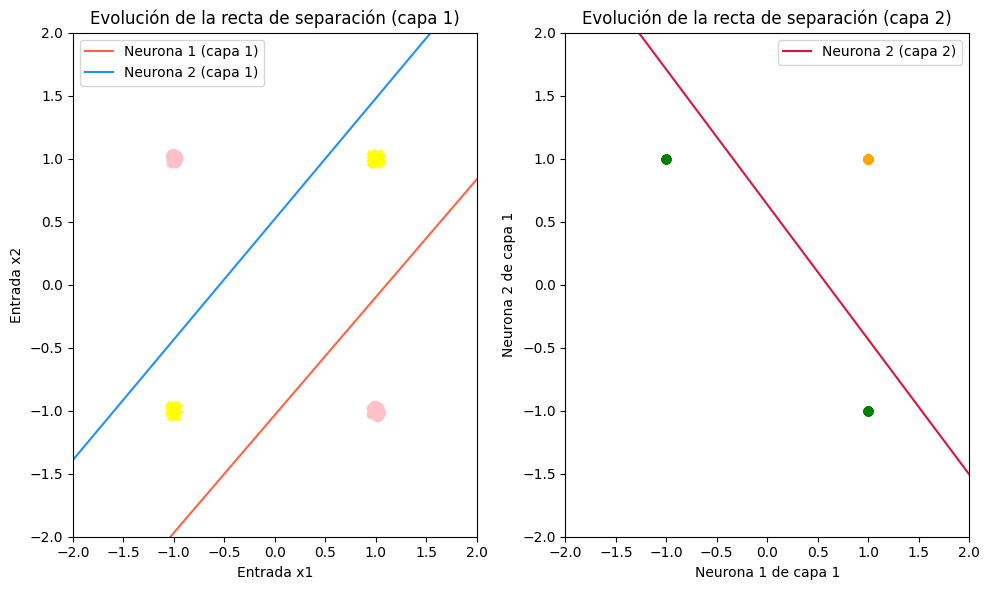

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].set(xlim=[-2,2],ylim=[-2,2],xlabel='Entrada x1',ylabel='Entrada x2',title='Evolución de la recta de separación (capa 1)')
ax[1].set(xlim=[-2,2],ylim=[-2,2],xlabel='Neurona 1 de capa 1',ylabel='Neurona 2 de capa 1',title='Evolución de la recta de separación (capa 2)')

# Capa 1
# Puntos

for i in range(len(Y_tst)):
  if Y_tst[i] == -1:
    ax[0].scatter(X_tst[i, 1], X_tst[i, 2], marker='x', color="yellow", alpha=0.9)
  else: 
    ax[0].scatter(X_tst[i, 1], X_tst[i, 2], marker='o', color="pink", alpha=0.9)


xs = np.linspace(-3, 3, 200) 

print(w[0])
w10 = w[0][0][0]
w11 = w[0][0][1]
w12 = w[0][0][2]

w20 = w[0][1][0]
w21 = w[0][1][1]
w22 = w[0][1][2]

recta_nuerona11 =  (w10 / w12) - (w11/w12) * xs
recta_neurona12 = (w20 / w22) - (w21/w22) * xs
ax[0].plot(xs, recta_nuerona11, label='Neurona 1 (capa 1)', color="tomato")
ax[0].plot(xs, recta_neurona12, label='Neurona 2 (capa 1)', color="dodgerblue")
ax[0].legend()

# Capa 2
# Puntos

for i in range(len(y_saved)):
  x1 = salidas_capa_oculta[i][0]
  x2 = salidas_capa_oculta[i][1]
  if (y_saved[i] == 1): # Según resultado esperado de la entrada:
    ax[1].scatter(x1,x2, color='green') 
  else: ax[1].scatter(x1,x2, color='orange')
 

recta_neurona21 = (w[1][0][0]/w[1][0][2]) - (w[1][0][1]/w[1][0][2]) * xs
ax[1].plot(xs, recta_neurona21, label="Neurona 2 (capa 2)", color="crimson")
ax[1].legend()


plt.tight_layout()
plt.show()